計算 DTW 距離矩陣中，請稍候...
DTW 距離矩陣計算完成。


c:\Users\jhbai\Anaconda\envs\MachineLearningEnv\Lib\site-packages\sklearn\manifold\_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


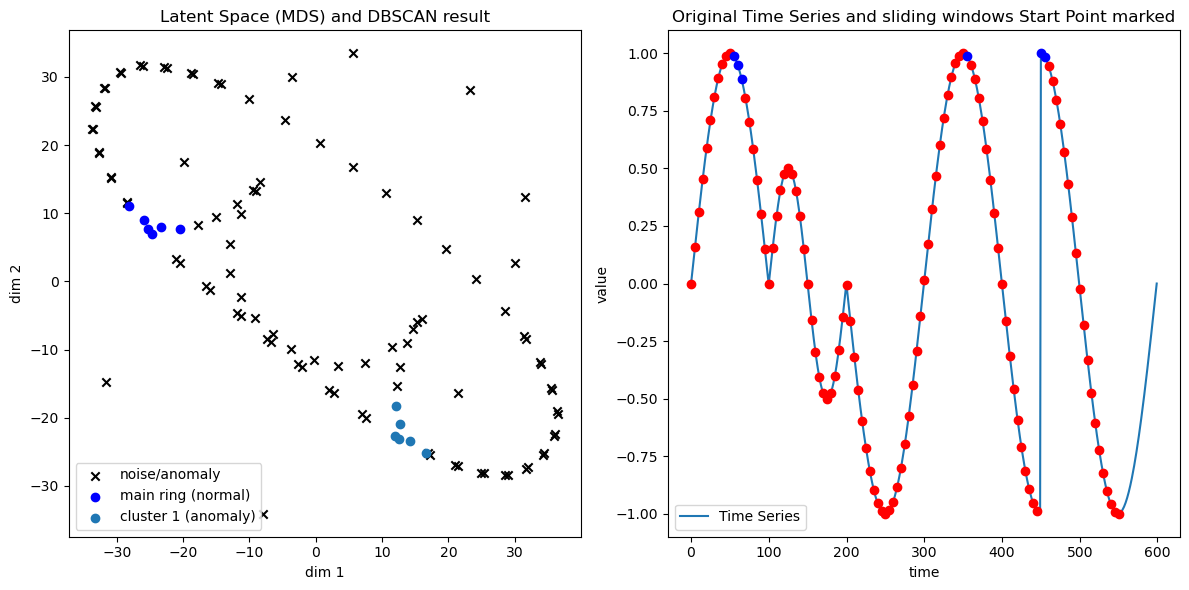


DBSCAN 分群結果：
主要環 (正常) 群標籤: 0
總共 windows 數: 111
偵測到的異常 windows 數: 105


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
from sklearn.manifold import MDS
from sklearn.cluster import DBSCAN
from collections import Counter

# 1. 產生測試資料
# 正常資料：週期性正弦波 (模擬主要環)
t = np.linspace(0, 4*np.pi, 400)
normal_signal = np.sin(t)

# 異常資料：在中間插入兩段不同頻率或形狀的訊號，模擬異常環
anomaly_signal1 = 0.5 * np.sin(t[:100]*2)  # 頻率加倍
anomaly_signal2 = np.cos(t[:100])           # 另一種形狀

# 將資料組合：先正常一段，再接異常，再正常，再異常，再正常
signal = np.concatenate([normal_signal[:100], anomaly_signal1, normal_signal[100:250], anomaly_signal2, normal_signal[250:]])

# 2. 利用 sliding windows 將時間序列分割
def sliding_windows(data, window_size, step):
    windows = []
    indices = []
    for i in range(0, len(data) - window_size + 1, step):
        windows.append(data[i:i+window_size])
        indices.append(i)
    return np.array(windows), indices

window_size = 50
step = 5
windows, win_indices = sliding_windows(signal, window_size, step)
num_windows = windows.shape[0]

# 3. 計算所有 sliding windows 間的 DTW 距離矩陣
dtw_distance_matrix = np.zeros((num_windows, num_windows))
print("計算 DTW 距離矩陣中，請稍候...")
for i in range(num_windows):
    for j in range(i, num_windows):
        # 使用 fastdtw 計算 DTW 距離
        distance, _ = fastdtw(windows[i], windows[j])
        dtw_distance_matrix[i, j] = distance
        dtw_distance_matrix[j, i] = distance
print("DTW 距離矩陣計算完成。")

# 4. 利用 MDS 將距離矩陣轉換為2D latent space 表示
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
latent_coords = mds.fit_transform(dtw_distance_matrix)

# 5. 使用 DBSCAN 進行基於密度的分群
# 設定 DBSCAN 參數：eps 可根據 latent space 散佈調整；min_samples 依資料量調整
dbscan = DBSCAN(eps=3.0, min_samples=5)
labels = dbscan.fit_predict(latent_coords)

# 找出主要環所在的群：通常點數最多的 cluster 為正常環
label_counts = Counter(labels[labels != -1])
if label_counts:
    main_cluster_label = label_counts.most_common(1)[0][0]
else:
    main_cluster_label = -1  # 若全部標記為噪音
# 將非主要群的點視為異常
anomaly_mask = (labels != main_cluster_label)

# 6. 繪圖顯示結果
plt.figure(figsize=(12, 6))

# 左圖：latent space 上的 DBSCAN 結果
plt.subplot(1, 2, 1)
for lab in np.unique(labels):
    idx = labels == lab
    if lab == -1:
        plt.scatter(latent_coords[idx, 0], latent_coords[idx, 1], c='k', marker='x', label='noise/anomaly')
    elif lab == main_cluster_label:
        plt.scatter(latent_coords[idx, 0], latent_coords[idx, 1], c='b', label='main ring (normal)')
    else:
        plt.scatter(latent_coords[idx, 0], latent_coords[idx, 1], label=f'cluster {lab} (anomaly)')
plt.title("Latent Space (MDS) and DBSCAN result")
plt.xlabel("dim 1")
plt.ylabel("dim 2")
plt.legend()

# 右圖：原始時間序列與 sliding window 位置標示
plt.subplot(1, 2, 2)
plt.plot(signal, label='Time Series')
# 標示每個 window 的起點，異常的用紅色圓點，正常的用藍色
for idx, lab in zip(win_indices, labels):
    if lab == main_cluster_label:
        plt.plot(idx, signal[idx], 'bo')
    else:
        plt.plot(idx, signal[idx], 'ro')
plt.title("Original Time Series and sliding windows Start Point marked")
plt.xlabel("time")
plt.ylabel("value")
plt.legend()

plt.tight_layout()
plt.show()

# 7. 異常偵測結果輸出
print("\nDBSCAN 分群結果：")
print("主要環 (正常) 群標籤:", main_cluster_label)
print("總共 windows 數:", num_windows)
print("偵測到的異常 windows 數:", np.sum(anomaly_mask))


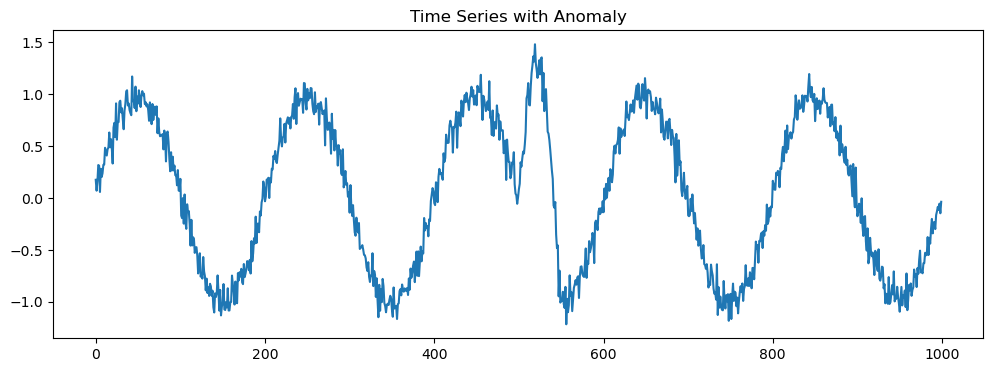

Number of windows: 96


c:\Users\jhbai\Anaconda\envs\MachineLearningEnv\Lib\site-packages\sklearn\manifold\_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


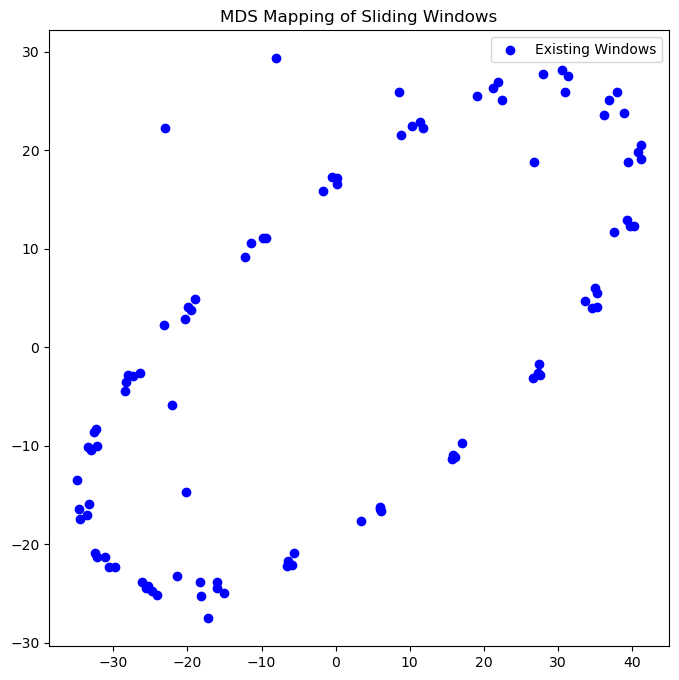

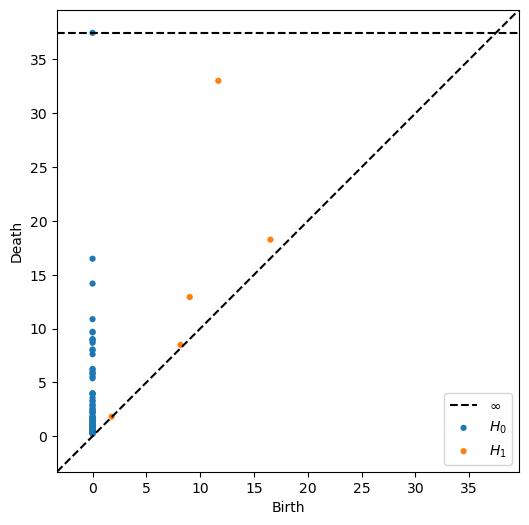

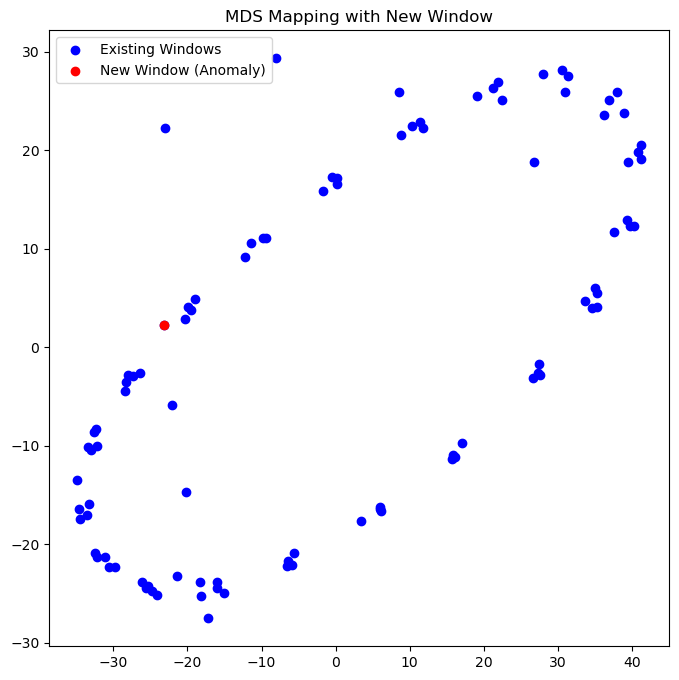

新窗口屬於現有環，未檢測到異常。


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
from sklearn.manifold import MDS
from ripser import ripser
from persim import plot_diagrams

# 1. 生成測試資料
np.random.seed(0)
n = 1000  # 時間序列長度
t = np.linspace(0, 10 * np.pi, n)
normal_series = np.sin(t) + 0.1 * np.random.randn(n)  # 正常週期性序列

# 加入異常模式
anomaly_start = 500
anomaly_end = 550
normal_series[anomaly_start:anomaly_end] += 2 * np.sin(2 * t[anomaly_start:anomaly_end])

plt.figure(figsize=(12, 4))
plt.plot(normal_series)
plt.title('Time Series with Anomaly')
plt.show()

# 2. Sliding Windows 提取
def sliding_windows(series, window_size, step):
    windows = []
    for i in range(0, len(series) - window_size + 1, step):
        windows.append(series[i:i + window_size])
    return np.array(windows)

window_size = 50  # 窗口大小
step = 10         # 步長
windows = sliding_windows(normal_series, window_size, step)
print(f"Number of windows: {windows.shape[0]}")

# 3. DTW 距離計算
def compute_dtw_distance_matrix(windows):
    n = len(windows)
    distance_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            distance, _ = fastdtw(windows[i], windows[j])
            distance_matrix[i, j] = distance
            distance_matrix[j, i] = distance
    return distance_matrix

distance_matrix = compute_dtw_distance_matrix(windows)

# 4. MDS 映射
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=0)
X_mds = mds.fit_transform(distance_matrix)

# 視覺化 MDS 映射
plt.figure(figsize=(8, 8))
plt.scatter(X_mds[:, 0], X_mds[:, 1], c='blue', label='Existing Windows')
plt.title('MDS Mapping of Sliding Windows')
plt.legend()
plt.show()

# 5. 環檢測（使用持久同調）
diagrams = ripser(X_mds)['dgms']
plt.figure(figsize=(8, 6))
plot_diagrams(diagrams, show=True)
# H1 的持久條形圖表示環狀結構，長條形圖表示顯著的環

# 6. 異常檢測：新窗口映射
# 提取異常窗口
new_window = normal_series[anomaly_start:anomaly_start + window_size]
new_distances = np.array([fastdtw(new_window, w)[0] for w in windows])

# 近似新窗口在 MDS 空間中的位置（使用加權平均法，簡單但不精確）
weights = 1 / (new_distances + 1e-5)  # 避免除以零
new_point = np.sum(X_mds * weights[:, np.newaxis], axis=0) / np.sum(weights)

# 視覺化新窗口
plt.figure(figsize=(8, 8))
plt.scatter(X_mds[:, 0], X_mds[:, 1], c='blue', label='Existing Windows')
plt.scatter(new_point[0], new_point[1], c='red', label='New Window (Anomaly)')
plt.title('MDS Mapping with New Window')
plt.legend()
plt.show()

# 7. 判斷是否形成新環
# 計算新點與現有點的距離，檢查是否遠離主要環
distances_to_existing = np.sqrt(np.sum((X_mds - new_point) ** 2, axis=1))
threshold = np.percentile(distances_to_existing, 95)  # 使用 95 分位數作為閾值
if min(distances_to_existing) > threshold:
    print("檢測到新環：新窗口可能是異常模式！")
else:
    print("新窗口屬於現有環，未檢測到異常。")